# 04 - Modelado No Supervisado
## Clustering de pozos segun su curva de produccion (Vaca Muerta / YPF)

**Objetivo:** agrupar los pozos en familias segun como es su curva de
produccion (cuanto llegaron a producir, que tan rapido declinan, que
antiguedad tienen y que relacion gas/petroleo tienen), usando K-Means.

La idea es entender si hay grupos de pozos con comportamientos bien
distintos entre si, y en particular revisar si los pozos con picos de
produccion muy altos -que en el notebook 03 el modelo supervisado no
lograba predecir bien- forman un grupo aparte o estan repartidos al azar
entre todos los clusters.

In [7]:
import sys
import os

sys.path.append("..")

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print("Carpeta de trabajo actual:", os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

sns.set_theme(style="whitegrid")
%matplotlib inline

Carpeta de trabajo actual: /Users/cristianaguilera/Desktop/proyecto-ds-ypf


## Paso 1: Cargar el dataset con las variables ya creadas

Usamos el mismo archivo que el notebook 03 (`data/processed/produccion_con_features.csv`),
generado en el notebook 02. Tiene una fila por pozo-mes.

In [8]:
df = pd.read_csv("data/processed/produccion_con_features.csv")
print(df.shape)
df.head()

(421046, 49)


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,antiguedad_meses,prod_pet_mes_anterior,prod_gas_mes_anterior,declinacion_pet,declinacion_gas,ratio_gas_petroleo,prod_pet_acumulada,prod_gas_acumulada,formacion_cod,cuenca_cod
0,PEL,2006,2,3640,0.000,0.000,0.000,0.0,0.0,0.0,...,1,NaN,NaN,NaN,NaN,NaN,0.000,0.000,27,2
1,PEL,2006,3,3640,30.808,1.731,30.570,0.0,0.0,0.0,...,2,0.000,0.000,NaN,NaN,0.056187,30.808,1.731,27,2
2,PEL,2006,4,3640,76.609,3.713,46.479,0.0,0.0,0.0,...,3,30.808,1.731,1.486659,1.145003,0.048467,107.417,5.444,27,2
3,PEL,2006,5,3640,63.273,4.202,50.536,0.0,0.0,0.0,...,4,76.609,3.713,-0.174079,0.131699,0.066411,170.690,9.646,27,2
4,PEL,2006,6,3640,55.043,4.373,52.062,0.0,0.0,0.0,...,5,63.273,4.202,-0.130071,0.040695,0.079447,225.733,14.019,27,2


## Paso 2: Resumir cada pozo en una sola fila

K-Means necesita que cada fila sea una observacion a agrupar. Como
nuestro dataset tiene una fila por pozo-mes, primero resumimos cada pozo
en 4 variables (las mismas que ya veniamos usando en el modelo
supervisado, resumidas por pozo):

- **pico_prod_pet:** la produccion mas alta que tuvo el pozo en toda su
  vida util.
- **declinacion_promedio:** cuanto declina en promedio mes a mes.
- **antiguedad_total:** cuantos meses de historia tiene cargados.
- **ratio_gas_pet_promedio:** relacion promedio entre gas y petroleo.

`declinacion_pet_anterior` no viene en el CSV (se calcula en el notebook
03 a partir de `declinacion_pet`), asi que la recalculamos aca tambien.

In [9]:
def armar_resumen_por_pozo(df):
    # Paso 0: declinacion_pet_anterior no viene en el CSV, la calculamos
    # igual que en el notebook 03 (declinacion del mes PASADO, sin fuga de datos)
    df["declinacion_pet_anterior"] = df.groupby("idpozo")["declinacion_pet"].shift(1)

    # Paso 1: pico historico de produccion de petroleo de cada pozo
    pico = df.groupby("idpozo")["prod_pet"].max().rename("pico_prod_pet")

    # Paso 2: declinacion promedio del pozo a lo largo de su vida
    declinacion_prom = df.groupby("idpozo")["declinacion_pet_anterior"].mean().rename("declinacion_promedio")

    # Paso 3: antiguedad total que alcanzo a tener el pozo (en meses)
    antiguedad = df.groupby("idpozo")["antiguedad_meses"].max().rename("antiguedad_total")

    # Paso 4: ratio gas/petroleo promedio del pozo
    ratio_prom = df.groupby("idpozo")["ratio_gas_petroleo"].mean().rename("ratio_gas_pet_promedio")

    # Paso 5: juntamos las 4 variables en un solo dataframe, una fila por pozo
    resumen = pd.concat([pico, declinacion_prom, antiguedad, ratio_prom], axis=1)

    # Paso 6: sacamos pozos que quedaron con datos faltantes
    # (tipicamente pozos con muy pocos meses de historia cargados)
    resumen = resumen.dropna()

    return resumen

resumen_pozos = armar_resumen_por_pozo(df)
print(resumen_pozos.shape)
resumen_pozos.head()

(4343, 4)


,pico_prod_pet,declinacion_promedio,antiguedad_total,ratio_gas_pet_promedio
idpozo,,,,
3640,164.53200,0.033052,246,0.107804
8043,82.93006,0.147327,246,6.632241
10073,328.00000,0.349296,247,187.862166
11191,62.77200,0.183218,247,37.551357
11641,13.79311,0.035667,246,36.387140


## Paso 3: Escalar las variables antes de agrupar

K-Means agrupa segun la distancia entre puntos. Si dejamos las variables
en su escala original, `pico_prod_pet` (que llega a cientos) pesaria
muchisimo mas que `declinacion_promedio` (que es un numero chico, tipo
0.03-0.35), y el agrupamiento terminaria basado casi solo en el pico de
produccion. Por eso escalamos todas las variables para que tengan la
misma importancia de entrada (media 0, desvio estandar 1).

In [10]:
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(resumen_pozos)

print(datos_escalados.shape)
datos_escalados[:5]

(4343, 4)


array([[-0.88534307, -0.01637851,  2.80701463, -0.02479461],
       [-0.91234945, -0.01636954,  2.80701463, -0.02447425],
       [-0.83124291, -0.01635369,  2.8242311 , -0.01557547],
       [-0.91902081, -0.01636672,  2.8242311 , -0.02295605],
       [-0.9352305 , -0.01637831,  2.80701463, -0.02301322]])

## Paso 4: Elegir cuantos clusters (k) usar - metodo del codo

K-Means necesita que le digamos de antemano cuantos grupos (k) buscar. No
hay una respuesta unica: probamos varios valores de k y graficamos la
inercia (que tan compactos quedan los puntos dentro de cada cluster)
para cada uno. Buscamos el "codo" de la curva: el punto donde agregar
mas clusters deja de mejorar mucho.

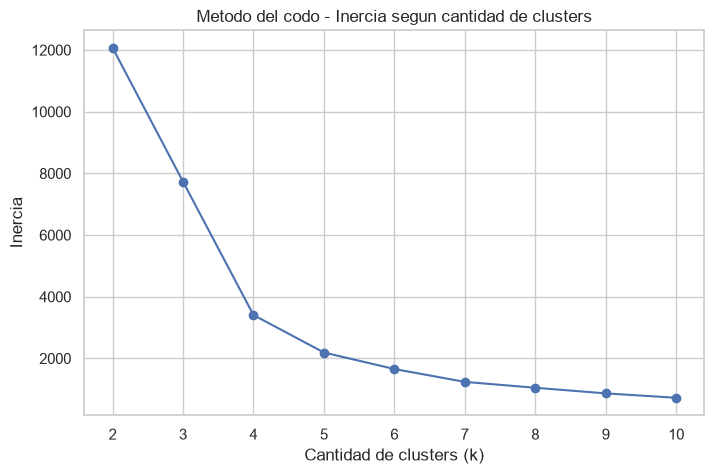

In [11]:
inercias = []
valores_k = range(2, 11)

for k in valores_k:
    modelo_prueba = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    modelo_prueba.fit(datos_escalados)
    inercias.append(modelo_prueba.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(valores_k), inercias, marker="o")
plt.title("Metodo del codo - Inercia segun cantidad de clusters")
plt.xlabel("Cantidad de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(list(valores_k))
plt.show()

**Como leer este grafico:** buscamos el punto donde la curva deja de
bajar fuerte y se aplana. Ese valor de k es un buen candidato. Lo
confirmamos con una segunda metrica en el paso siguiente, porque el codo
a veces es dificil de leer a simple vista.

## Paso 5: Confirmar k con el silhouette score

El silhouette score mide que tan bien separados quedan los clusters (va
de -1 a 1; mas cerca de 1 es mejor). A diferencia de la inercia, sirve
para comparar distintos valores de k de forma mas objetiva.

k=2 -> silhouette=0.534
k=3 -> silhouette=0.538
k=4 -> silhouette=0.542
k=5 -> silhouette=0.452
k=6 -> silhouette=0.457
k=7 -> silhouette=0.434
k=8 -> silhouette=0.439
k=9 -> silhouette=0.413
k=10 -> silhouette=0.416


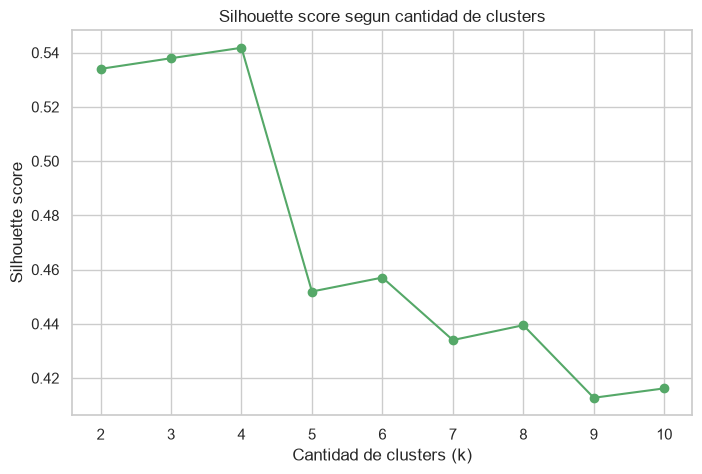

In [12]:
silhouettes = []

for k in valores_k:
    modelo_prueba = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    etiquetas_prueba = modelo_prueba.fit_predict(datos_escalados)
    score = silhouette_score(datos_escalados, etiquetas_prueba)
    silhouettes.append(score)
    print(f"k={k} -> silhouette={score:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(list(valores_k), silhouettes, marker="o", color="#55A868")
plt.title("Silhouette score segun cantidad de clusters")
plt.xlabel("Cantidad de clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(list(valores_k))
plt.show()

**Decision:** completar `K_ELEGIDO` en la celda de abajo mirando los
dos graficos de arriba (el codo de la inercia y el pico del silhouette
score). Ademas de los numeros, tener en cuenta que el k elegido tiene
que ser interpretable para la defensa -no tiene mucho sentido quedarse
con 9 clusters si despues no se puede explicar que diferencia a cada
uno-.

In [13]:
# Completar con el valor de k elegido mirando el codo y el silhouette de arriba
K_ELEGIDO = 4  # <-- cambiar segun lo que se vea en los graficos

## Paso 6: Entrenar el modelo final de K-Means

Usamos `init="k-means++"` (mejor que arrancar los centros al azar,
reduce el riesgo de quedar en un mal optimo local) y `n_init=10` (prueba
10 inicializaciones distintas y se queda con la mejor), que son los
hiperparametros recomendados para K-Means salvo que el dataset sea
enorme (no es nuestro caso: 4 variables, unos pocos miles de pozos).

In [14]:
modelo_kmeans = KMeans(
    n_clusters=K_ELEGIDO,
    init="k-means++",
    n_init=10,
    random_state=42,
)

resumen_pozos["cluster"] = modelo_kmeans.fit_predict(datos_escalados)

resumen_pozos["cluster"].value_counts().sort_index()

cluster
0    2396
1    1945
2       1
3       1
Name: count, dtype: int64

## Paso 7: Caracterizar cada cluster

Con cada pozo ya asignado a un cluster, miramos el promedio de cada
variable por grupo. Esto es lo que despues se traduce en una
descripcion en palabras de cada cluster para la defensa (por ejemplo:
"pozos de produccion alta y declinacion rapida" o "pozos chicos y
estables").

In [15]:
perfil_clusters = resumen_pozos.groupby("cluster").mean(numeric_only=True).round(3)
perfil_clusters["cantidad_pozos"] = resumen_pozos.groupby("cluster").size()
perfil_clusters

,pico_prod_pet,declinacion_promedio,antiguedad_total,ratio_gas_pet_promedio,cantidad_pozos
cluster,,,,,
0,633.635,3.421,122.180,351.150,2396
1,5559.973,30.126,34.606,6.250,1945
2,0.005,-1.000,61.000,1339944.400,1
3,339.237,839563.689,172.000,50.625,1


**Que mirar en esta tabla:** comparar fila por fila cual cluster
tiene el pico de produccion mas alto, cual declina mas rapido, cual es
mas viejo (mayor antiguedad), y cual tiene mas gas relativo al petroleo.
Con eso alcanza para escribir una descripcion corta de cada grupo.

## Paso 8: Visualizar los clusters en 2 dimensiones (PCA)

Tenemos 4 variables, que no se pueden graficar todas juntas en un plano.
PCA (Analisis de Componentes Principales) resume esas 4 variables en 2
"ejes" nuevos que conservan la mayor parte de la informacion posible,
solo para poder ver en un grafico si los clusters quedan separados.

Varianza explicada por cada componente: [0.40176905 0.25023699]


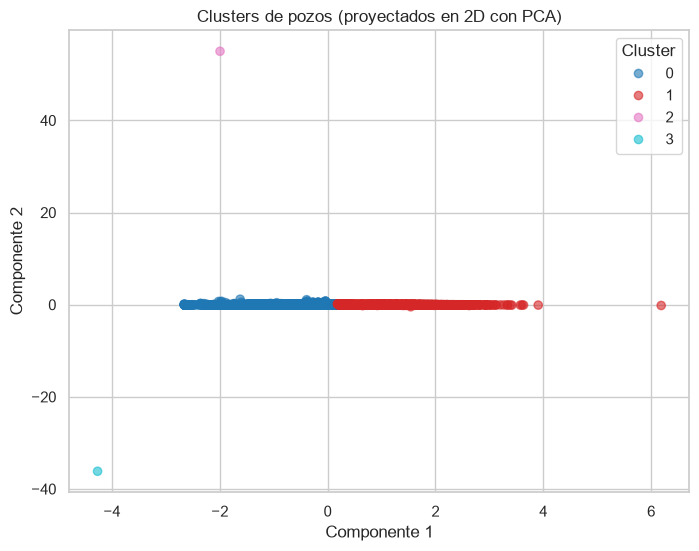

In [16]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(datos_escalados)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    componentes[:, 0], componentes[:, 1],
    c=resumen_pozos["cluster"], cmap="tab10", alpha=0.6
)
plt.title("Clusters de pozos (proyectados en 2D con PCA)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

**Que deberiamos ver:** grupos de puntos del mismo color agrupados
entre si y razonablemente separados de los otros colores. Si los colores
aparecen todos mezclados, es señal de que el k elegido no esta separando
bien los datos y conviene revisar de nuevo los graficos del Paso 4 y 5.

## Paso 9: Comparar la curva de produccion real de un pozo tipico de cada cluster

Ademas de los numeros resumidos, conviene ver la curva real de
produccion mes a mes de un pozo representativo de cada cluster, para
confirmar visualmente que los grupos tienen sentido fisico y no son solo
un artificio estadistico.

Pozo representativo de cada cluster: {np.int32(0): np.int64(159496), np.int32(1): np.int64(162554), np.int32(2): np.int64(162450), np.int32(3): np.int64(137343)}


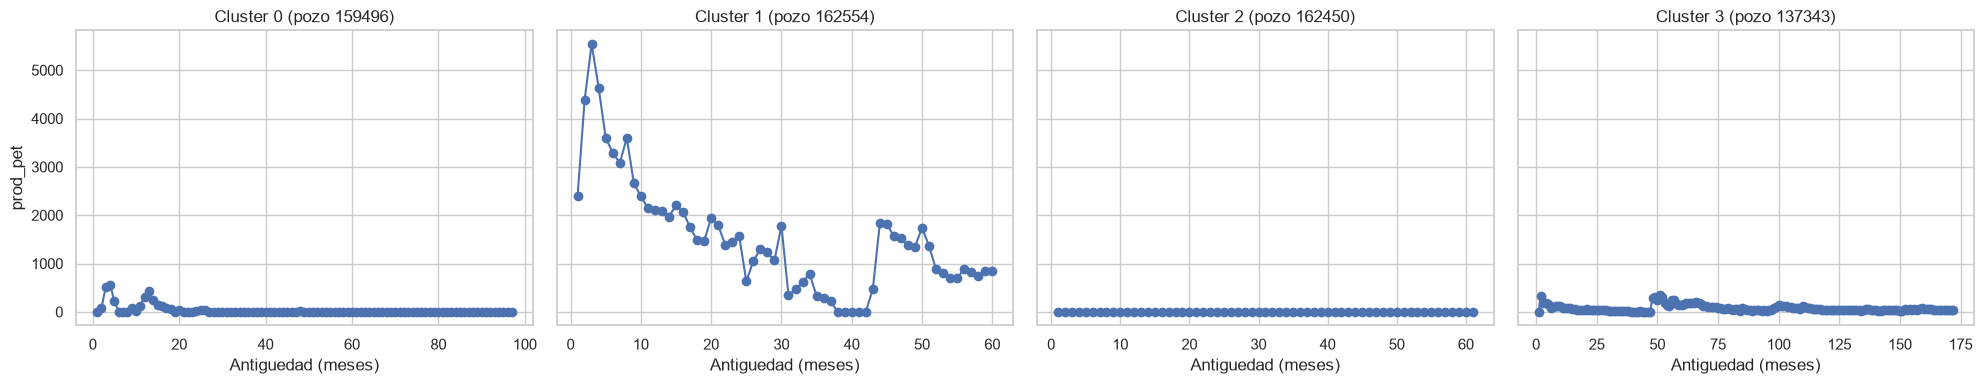

In [17]:
columnas_perfil = ["pico_prod_pet", "declinacion_promedio", "antiguedad_total", "ratio_gas_pet_promedio"]

# De cada cluster, elegimos el pozo mas cercano al promedio de ese cluster
pozos_representativos = {}

for cluster_id in sorted(resumen_pozos["cluster"].unique()):
    pozos_del_cluster = resumen_pozos[resumen_pozos["cluster"] == cluster_id]
    promedio_cluster = pozos_del_cluster[columnas_perfil].mean()
    distancias = ((pozos_del_cluster[columnas_perfil] - promedio_cluster) ** 2).sum(axis=1)
    pozos_representativos[cluster_id] = distancias.idxmin()

print("Pozo representativo de cada cluster:", pozos_representativos)

fig, axes = plt.subplots(1, len(pozos_representativos), figsize=(5 * len(pozos_representativos), 4), sharey=True)

for ax, (cluster_id, idpozo) in zip(axes, pozos_representativos.items()):
    datos_pozo = df[df["idpozo"] == idpozo].sort_values("antiguedad_meses")
    ax.plot(datos_pozo["antiguedad_meses"], datos_pozo["prod_pet"], marker="o")
    ax.set_title(f"Cluster {cluster_id} (pozo {idpozo})")
    ax.set_xlabel("Antiguedad (meses)")

axes[0].set_ylabel("prod_pet")
plt.tight_layout()
plt.show()

## Paso 10: Relacionar los clusters con la limitacion del modelo supervisado

En el notebook 03 vimos que el modelo (XGBoost y LightGBM por igual)
subestima sistematicamente los pozos con picos de produccion muy altos
(>10.000). Ahora que tenemos los pozos agrupados, podemos revisar: esos
pozos problematicos, ¿caen todos en un mismo cluster o estan repartidos
entre varios? Si se concentran en un cluster puntual, es un indicio mas
fuerte de que son un grupo con comportamiento distinto (por ejemplo,
pozos reestimulados), y no simplemente ruido disperso.

In [18]:
pozos_pico_alto = resumen_pozos[resumen_pozos["pico_prod_pet"] > 10000]

print("Cantidad de pozos con pico > 10.000:", len(pozos_pico_alto))
pozos_pico_alto["cluster"].value_counts().sort_index()

Cantidad de pozos con pico > 10.000: 94


cluster
1    94
Name: count, dtype: int64

## Paso 11: Guardar los resultados

Guardamos dos cosas: 1) la tabla de pozos con su cluster asignado, para
poder cruzarla con otros analisis mas adelante, y 2) el modelo de
K-Means y el scaler ya entrenados, por si hace falta asignarle un
cluster a un pozo nuevo sin tener que re-entrenar todo de cero.

In [19]:
os.makedirs("data/processed", exist_ok=True)
resumen_pozos.to_csv("data/processed/pozos_con_cluster.csv")

os.makedirs("models", exist_ok=True)
joblib.dump(modelo_kmeans, "models/modelo_clustering_kmeans.joblib")
joblib.dump(scaler, "models/scaler_clustering.joblib")

print("Guardado:")
print("- data/processed/pozos_con_cluster.csv")
print("- models/modelo_clustering_kmeans.joblib")
print("- models/scaler_clustering.joblib")

Guardado:
- data/processed/pozos_con_cluster.csv
- models/modelo_clustering_kmeans.joblib
- models/scaler_clustering.joblib


## Conclusiones

- Se resumio cada pozo en 4 variables (pico de produccion, declinacion
  promedio, antiguedad total y ratio gas/petroleo), partiendo de las
  mismas features ya usadas en el modelo supervisado del notebook 03.
- Se escalaron las variables antes de aplicar K-Means: sin escalar,
  `pico_prod_pet` dominaria el agrupamiento por tener una escala mucho
  mayor que las demas.
- Se eligio k = **completar** combinando el metodo del codo y el
  silhouette score (completar tambien con una breve justificacion una
  vez corridos los graficos de los Pasos 4 y 5).
- Se caracterizo cada cluster (tabla de promedios) y se visualizo en 2D
  con PCA para confirmar que quedan razonablemente separados.
- Se reviso si los pozos con picos de produccion muy altos -la
  limitacion conocida del modelo supervisado- se concentran en un
  cluster en particular: **completar con el resultado de el Paso 10**.

**Proximo paso:** con esto queda cerrado el modelado no supervisado. Lo
que resta para la entrega final es evaluar SHAP y/o Optuna sobre el
modelo supervisado (opcional, segun tiempo), y armar la API (FastAPI) +
Dockerfile + documentacion final en el README.